In [1]:
from pathlib import Path

import scarf
import scarf.plotting as splt

DATASET = "bastidas-ponce_4K_pancreas-d15_rnaseq"
repo_root = Path(scarf.__file__).resolve().parents[1]
zarr_path = (
    repo_root
    / "docs"
    / "source"
    / "vignettes"
    / "scarf_datasets"
    / DATASET
    / "data.zarr"
)
if not zarr_path.exists():
    scarf.fetch_dataset(
        dataset_name=DATASET,
        save_path="scarf_datasets",
        as_zarr=True,
    )
    zarr_path = Path("scarf_datasets") / DATASET / "data.zarr"

ds = scarf.DataStore(str(zarr_path), nthreads=4, default_assay="RNA")

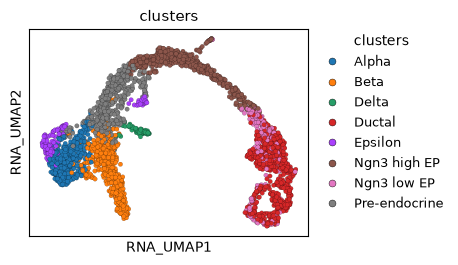

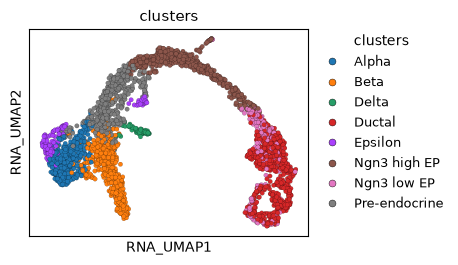

In [2]:
emb = splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="clusters",
    show=False,
)
emb.figure

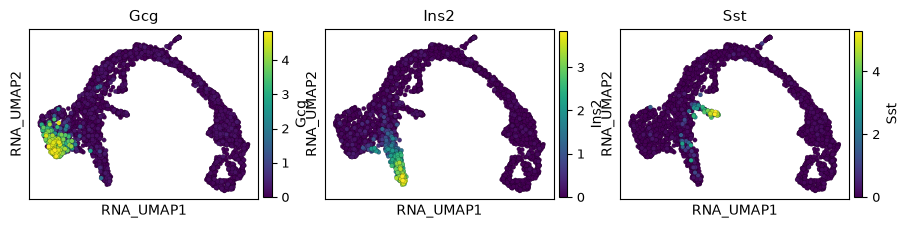

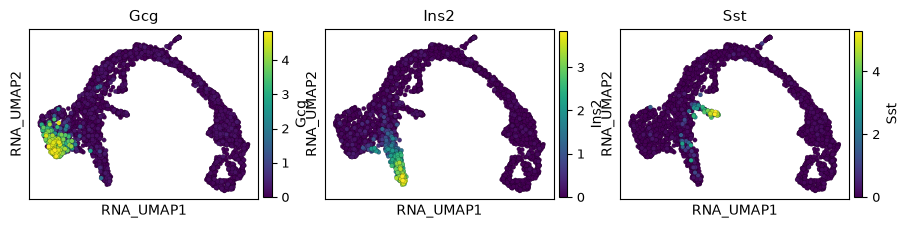

In [3]:
genes = ["Gcg", "Ins2", "Sst"]
emb2 = splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by=genes,
    normalization=splt.NormalizationSpec(transform="log1p"),
    sort_values=True,
    show=False,
)
emb2.figure

In [4]:
from pathlib import Path

out = Path("scarf_datasets") / "plotting_showcase_embedding.tiff"
out.parent.mkdir(parents=True, exist_ok=True)
emb.save(out, dpi=300, exact_size=True, provenance_sidecar=True)
assert out.exists()
assert out.with_suffix(".tiff.json").exists()
emb.close()
emb2.close()

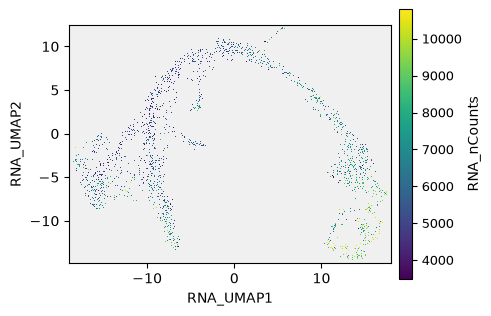

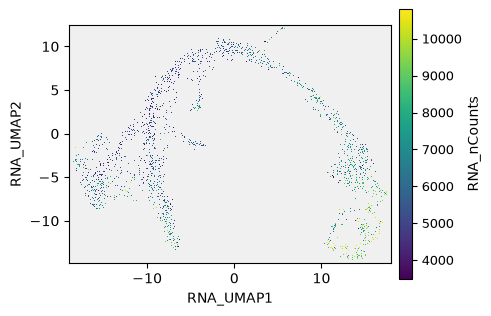

In [5]:
raster = splt.embedding_raster(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_nCounts",
    pixels=400,
    show=False,
)
raster.figure

In [6]:
raster.close()

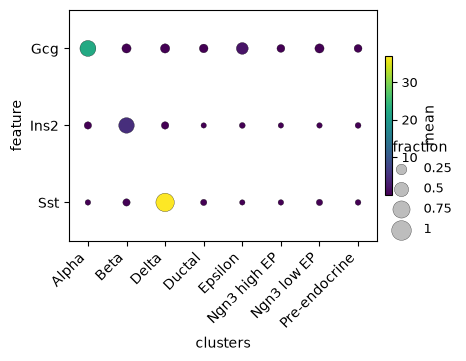

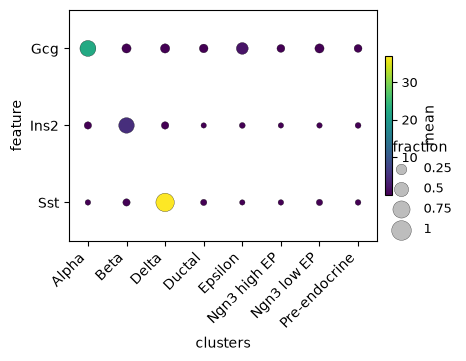

In [7]:
# Toy sample labels for the demo (replace with your real sample column).
n = len(ds.cells.active_index("I"))
ds.cells.insert(
    "demo_sample",
    [f"s{i % 8}" for i in range(n)],
    overwrite=True,
)

dp = splt.dotplot(
    ds,
    features={"endocrine": ["Gcg", "Ins2", "Sst"]},
    group_by="clusters",
    sample_by="demo_sample",
    show=False,
)
dp.figure

In [8]:
mp = splt.matrixplot(
    ds,
    features=["Gcg", "Ins2", "Sst"],
    group_by="clusters",
    value="mean",
    show=False,
)
mp.figure
mp.close()
dp.close()

,sample,category,proportion,n_cells,subject,condition
0,s0,Alpha,0.114754,49,d0,before
1,s1,Alpha,0.163934,70,d1,before
2,s2,Alpha,0.133489,57,d2,before
3,s3,Alpha,0.128806,55,d3,before
4,s4,Alpha,0.135831,58,d0,after


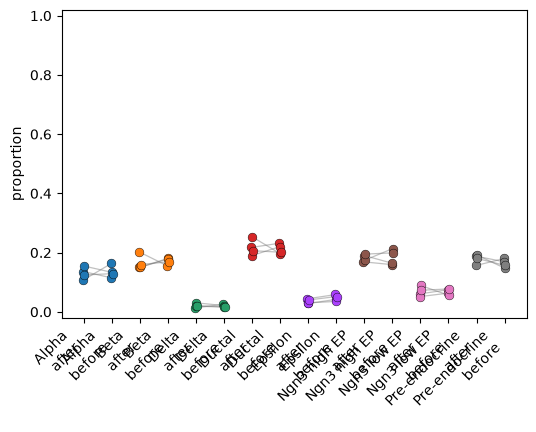

In [9]:
ds.cells.insert(
    "demo_subject",
    [f"d{i % 4}" for i in range(n)],
    overwrite=True,
)
ds.cells.insert(
    "demo_condition",
    ["before" if i % 8 < 4 else "after" for i in range(n)],
    overwrite=True,
)

comp = splt.composition(
    ds,
    category_by="clusters",
    study_design=splt.StudyDesign(
        sample_by="demo_sample",
        subject_by="demo_subject",
        condition_by="demo_condition",
    ),
    kind="per_sample",
    show=False,
)
comp.tables["per_sample"].head()

In [10]:
comp.figure
comp.close()

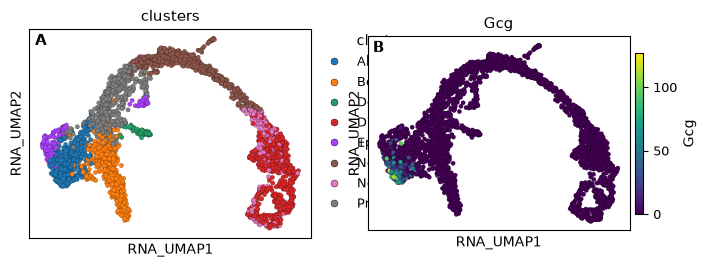

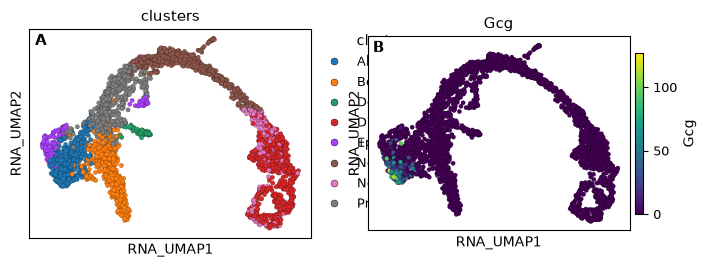

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplot_mosaic([["A", "B"]], figsize=(8, 3.5))
a = splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="clusters",
    target=axes["A"],
    show=False,
)
b = splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="Gcg",
    target=axes["B"],
    show=False,
)
splt.label_panels({"A": axes["A"], "B": axes["B"]}, labels=["A", "B"])
fig

In [12]:
# Opt-in bridge: returns a PlotResult when the call is compatible.
result = ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by="clusters",
    show_fig=False,
    use_plotting=True,
)
assert isinstance(result, splt.PlotResult)
result.close()
a.close()
b.close()
plt.close(fig)

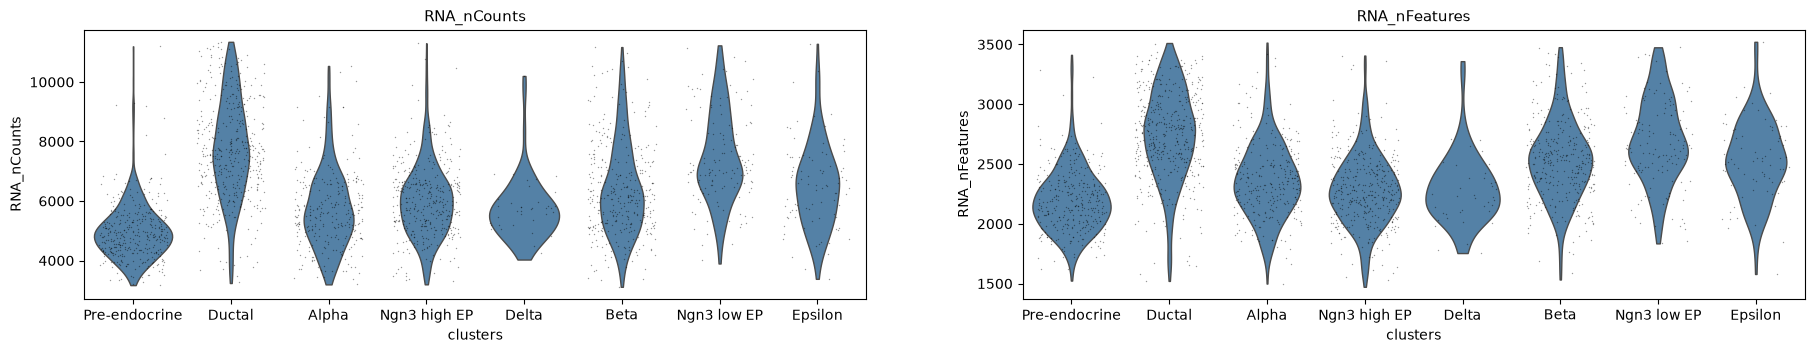

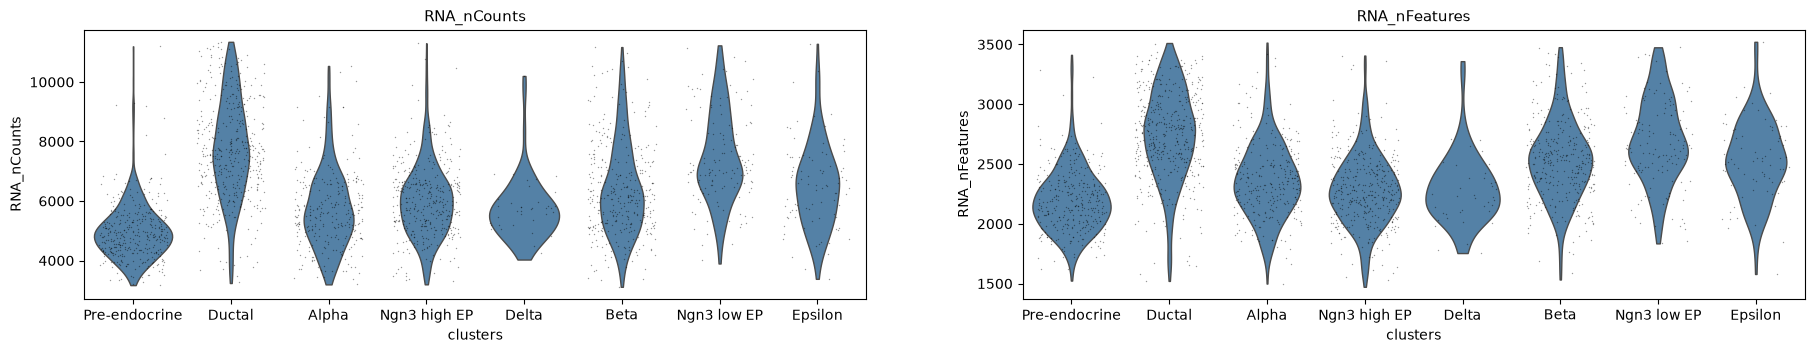

In [13]:
dist = splt.distribution(
    ds,
    keys=["RNA_nCounts", "RNA_nFeatures"],
    group_by="clusters",
    kind="violin",
    max_points=2000,
    seed=0,
    show=False,
)
dist.figure

In [14]:
hist = splt.distribution(ds, keys="RNA_nCounts", kind="hist", bins=40, show=False)
ecdf = splt.distribution(ds, keys="RNA_nCounts", kind="ecdf", show=False)
hist.close()
ecdf.close()
dist.close()